# Homework — Part A

MILK10k: 5,240 skin lesions, each with one dermoscopic and one clinical close-up image.
Reusable code lives in `../src/` and is imported here; the same functions are used by the Part B scripts.
The data folder is read from the environment variable `MILK10K_DIR` (see README).

In [1]:
import sys
sys.path.append("..")

import io
import os
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from src import config
from src.data import load_metadata, load_gt, add_labels, image_path, filter_available

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 20)
SEED = config.SEED
classes = config.CLASSES

meta = load_metadata()
gt = load_gt()
print("metadata:", meta.shape, " training_gt:", gt.shape)
meta.head(3)

metadata: (10480, 17)  training_gt: (5240, 12)


,isic_id,attribution,copyright_license,age_approx,anatom_site_general,anatom_site_special,concomitant_biopsy,diagnosis_1,diagnosis_2,diagnosis_3,diagnosis_4,diagnosis_confirm_type,image_manipulation,image_type,lesion_id,melanocytic,sex
0,ISIC_0051817,MILK study team,CC-BY-NC,70.0,upper extremity,NaN,True,Malignant,Malignant epidermal proliferations,"Squamous cell carcinoma, Invasive",NaN,histopathology,instrument only,dermoscopic,IL_1612768,NaN,male
1,ISIC_0073863,MILK study team,CC-BY-NC,5.0,NaN,NaN,True,Benign,Benign melanocytic proliferations,Nevus,"Nevus, Reed",histopathology,instrument only,dermoscopic,IL_2547802,True,female
2,ISIC_0075884,MILK study team,CC-BY-NC,10.0,upper extremity,NaN,True,Benign,Benign melanocytic proliferations,Nevus,"Nevus, Acral",histopathology,instrument only,clinical: close-up,IL_9270970,True,female


# A1 — pandas

## A1.1 Cross-check the two label files

In [2]:
# (a) same lesions in both files?
ids_meta, ids_gt = set(meta.lesion_id), set(gt.lesion_id)
print("only in metadata:", len(ids_meta - ids_gt), "| only in training_gt:", len(ids_gt - ids_meta))
assert ids_meta == ids_gt

only in metadata: 0 | only in training_gt: 0


In [3]:
# (b) exactly one class per row in the one-hot ground truth
row_sums = gt[classes].sum(axis=1)
print("rows that are not exactly one-hot:")
print(gt[row_sums != 1])
assert (row_sums == 1).all()

rows that are not exactly one-hot:
Empty DataFrame
Columns: [lesion_id, AKIEC, BCC, BEN_OTH, BKL, DF, INF, MAL_OTH, MEL, NV, SCCKA, VASC]
Index: []


In [4]:
# (c) 11-class label vs diagnosis_1, counted per lesion
labelled = add_labels(meta, gt)
lesions = labelled.drop_duplicates("lesion_id")
ct = pd.crosstab(lesions.dx, lesions.diagnosis_1)
print(ct)
multi = ct[(ct > 0).sum(axis=1) > 1]
print("\nclasses that map to more than one diagnosis_1 value:")
print(multi)

diagnosis_1  Benign  Indeterminate  Malignant
dx                                           
AKIEC             0            123        180
BCC               0              0       2522
BEN_OTH          44              0          0
BKL             544              0          0
DF               52              0          0
INF              50              0          0
MAL_OTH           0              0          9
MEL               0              0        450
NV              746              0          0
SCCKA             0              0        473
VASC             47              0          0

classes that map to more than one diagnosis_1 value:
diagnosis_1  Benign  Indeterminate  Malignant
dx                                           
AKIEC             0            123        180


In [5]:
# (d) the diagnosis hierarchy must be consistent: each diagnosis_3 -> one diagnosis_2, each diagnosis_2 -> one diagnosis_1
d3_to_d2 = meta.groupby("diagnosis_3").diagnosis_2.nunique()
d2_to_d1 = meta.groupby("diagnosis_2").diagnosis_1.nunique()
print("diagnosis_3 with >1 diagnosis_2:", (d3_to_d2 > 1).sum(), "| diagnosis_2 with >1 diagnosis_1:", (d2_to_d1 > 1).sum())
assert (d3_to_d2 == 1).all() and (d2_to_d1 == 1).all()
print("rows with missing diagnosis_3:", meta.diagnosis_3.isna().sum())

diagnosis_3 with >1 diagnosis_2: 0 | diagnosis_2 with >1 diagnosis_1: 0
rows with missing diagnosis_3: 158


In [6]:
# (e) lesion-level fields must be identical for the two images of a lesion
per_lesion = meta.groupby("lesion_id")[["age_approx", "sex", "anatom_site_general", "diagnosis_1"]].nunique(dropna=False)
print(per_lesion.max())
assert (per_lesion <= 1).all().all()

age_approx             1
sex                    1
anatom_site_general    1
diagnosis_1            1
dtype: int64


**Answer A1.1.** The two files describe exactly the same 5,240 lesions and every ground-truth row is a valid one-hot vector.
The diagnosis hierarchy is consistent (each `diagnosis_3` has one parent `diagnosis_2`, each `diagnosis_2` one `diagnosis_1`), and age, sex, site and `diagnosis_1` are identical for the two images of a lesion, so they are really lesion-level fields.
The one problem is (c): **AKIEC** maps to two `diagnosis_1` values (180 Malignant, 123 Indeterminate) — actinic keratosis / Bowen's disease is graded as either pre-malignant or malignant.
All other classes map to exactly one value. So `diagnosis_1` cannot always be derived from an 11-class prediction: a lesion predicted as AKIEC could be Malignant or Indeterminate, which is why we train on `diagnosis_1` directly (or keep both heads).

## A1.2 Five questions

In [7]:
# 1. BCC lesions in patients aged >= 70 on the head/neck
q1 = lesions[(lesions.dx == "BCC") & (lesions.age_approx >= 70) & (lesions.anatom_site_general == "head/neck")]
print("Q1: BCC, age >= 70, head/neck ->", q1.lesion_id.nunique(), "lesions")

Q1: BCC, age >= 70, head/neck -> 380 lesions


In [8]:
# 2. Which class has the highest share of 'altered' images?
altered = labelled.groupby("dx").image_manipulation.apply(lambda s: (s == "altered").mean())
print(f"Q2: highest share of altered images: {altered.idxmax()} ({altered.max():.1%}); overall {(labelled.image_manipulation == 'altered').mean():.1%}")

Q2: highest share of altered images: BEN_OTH (18.2%); overall 3.2%


In [9]:
# 3. Age range of melanoma patients
mel_age = lesions.loc[lesions.dx == "MEL", "age_approx"]
print(f"Q3: MEL age min {mel_age.min():.0f}, max {mel_age.max():.0f}, range {mel_age.max() - mel_age.min():.0f} years")

Q3: MEL age min 20, max 85, range 65 years


In [10]:
# 4. Does the class mix differ between lesions with and without a recorded site?
no_site = lesions.anatom_site_general.isna()
mix = pd.DataFrame({
    "site missing": lesions[no_site].dx.value_counts(normalize=True),
    "site known": lesions[~no_site].dx.value_counts(normalize=True),
}).fillna(0)
mix["diff_pp"] = (mix["site missing"] - mix["site known"]) * 100
print((mix * [100, 100, 1]).round(1).sort_values("diff_pp"))
biggest = mix.diff_pp.abs().idxmax()
print(f"Q4: largest difference: {biggest}, {mix.loc[biggest, 'diff_pp']:+.1f} percentage points ({no_site.mean():.0%} of lesions have no site)")

         site missing  site known  diff_pp
dx                                        
SCCKA             2.9        12.7     -9.8
AKIEC             2.0         8.0     -6.0
DF                0.5         1.3     -0.8
BKL              10.1        10.6     -0.5
INF               0.9         1.0     -0.1
BEN_OTH           0.8         0.9     -0.1
MAL_OTH           0.3         0.1      0.2
VASC              1.2         0.7      0.4
BCC              49.3        47.4      1.9
MEL              11.0         7.2      3.8
NV               21.1        10.1     11.0
Q4: largest difference: NV, +11.0 percentage points (37% of lesions have no site)


In [11]:
# 5. Confirmation type vs diagnosis_1
print((pd.crosstab(lesions.diagnosis_confirm_type, lesions.diagnosis_1, normalize="index") * 100).round(1))

diagnosis_1                             Benign  Indeterminate  Malignant
diagnosis_confirm_type                                                  
histopathology                            25.7            2.0       72.3
single contributor clinical assessment    87.1           10.7        2.2


**Answer Q5.** Histopathology-confirmed (biopsied) lesions are mostly Malignant, while lesions confirmed only by a clinician's assessment are almost all Benign.
A lesion is biopsied because it looked suspicious, so a dataset built mainly from biopsied lesions is **enriched with malignant cases** (selection bias): the class mix is far more malignant than what a GP sees in daily practice.

## A1.3 Lesion table (one row per lesion)

In [12]:
wide = meta.pivot(index="lesion_id", columns="image_type", values="isic_id")
wide = wide.rename(columns={config.DERM: "derm_id", config.CLINICAL: "clinical_id"})
wide = wide[["derm_id", "clinical_id"]]
wide.columns.name = None

lesion_cols = ["age_approx", "sex", "anatom_site_general", "diagnosis_1", "diagnosis_2", "diagnosis_3", "diagnosis_confirm_type"]
fields = meta.groupby("lesion_id")[lesion_cols].first()
dx = gt.set_index("lesion_id")[classes].idxmax(axis=1).rename("dx")

lesion_table = wide.join(fields).join(dx).reset_index()
assert len(lesion_table) == 5240
assert lesion_table[["derm_id", "clinical_id"]].notna().all().all()
assert lesion_table.lesion_id.is_unique
lesion_table.head()

,lesion_id,derm_id,clinical_id,age_approx,sex,anatom_site_general,diagnosis_1,diagnosis_2,diagnosis_3,diagnosis_confirm_type,dx
0,IL_0000652,ISIC_4671410,ISIC_8149219,70.0,male,head/neck,Malignant,Malignant adnexal epithelial proliferations - ...,Basal cell carcinoma,histopathology,BCC
1,IL_0003176,ISIC_5371928,ISIC_3904045,45.0,female,head/neck,Malignant,Malignant adnexal epithelial proliferations - ...,Basal cell carcinoma,histopathology,BCC
2,IL_0004688,ISIC_3624913,ISIC_0791494,50.0,male,lower extremity,Malignant,Malignant adnexal epithelial proliferations - ...,Basal cell carcinoma,histopathology,BCC
3,IL_0005081,ISIC_5186409,ISIC_5667730,45.0,male,head/neck,Malignant,Malignant epidermal proliferations,"Squamous cell carcinoma, Invasive",histopathology,SCCKA
4,IL_0006177,ISIC_1048297,ISIC_8803389,75.0,male,upper extremity,Malignant,Malignant adnexal epithelial proliferations - ...,Basal cell carcinoma,histopathology,BCC


In [13]:
# The same logic now lives in src/data.py -> build_lesion_table(); check both agree and save
from src.data import build_lesion_table
lt = build_lesion_table(meta)
pd.testing.assert_frame_equal(lt[lesion_table.columns], lesion_table)
config.OUTPUT_DIR.mkdir(exist_ok=True)
lt.to_csv(config.OUTPUT_DIR / "lesions.csv", index=False)
print("saved outputs/lesions.csv", lt.shape)

saved outputs/lesions.csv (5240, 11)


## A1.4 Task framing

**Input:** both images of a lesion (dermoscopic + clinical close-up). No metadata that leaks the label (`diagnosis_2–4`, `diagnosis_confirm_type`, `image_manipulation`).
**Output:** probabilities for Benign / Malignant / Indeterminate for the lesion.
**User and moment:** a dermatologist or GP at triage, when deciding whether a lesion needs a biopsy or referral.
**Metric:** balanced accuracy (the classes are very imbalanced, and plain accuracy rewards always predicting Malignant), reported together with **Malignant recall**.
**Worst error:** a missed malignancy (Malignant predicted as Benign) — it delays treatment; a false alarm only costs an extra biopsy.
**Differences from real use:** (1) the class mix is biopsy-enriched — about 69 % malignant here, far fewer in a real clinic, so precision would drop; (2) the images are curated, good-quality captures from specific devices and clinics, while real-world photos vary in device, lighting and quality.

# A2 — Pixels

## A2.1 Arrays, views and memory

In [14]:
p = image_path(lesion_table.derm_id.iloc[0])
img = Image.open(p).convert("RGB")
arr = np.array(img)
print("shape", arr.shape, "dtype", arr.dtype)

ops = {
    "flip left-right": (arr[:, ::-1],                    Image.Transpose.FLIP_LEFT_RIGHT),
    "flip up-down":    (arr[::-1],                       Image.Transpose.FLIP_TOP_BOTTOM),
    "rotate 90 (ccw)": (arr.transpose(1, 0, 2)[::-1],    Image.Transpose.ROTATE_90),
    "transpose":       (arr.transpose(1, 0, 2),          Image.Transpose.TRANSPOSE),
}
rows = []
for name, (np_result, pil_op) in ops.items():
    rows.append({
        "operation": name,
        "numpy shape": np_result.shape,
        "equal to Pillow": np.array_equal(np_result, np.array(img.transpose(pil_op))),
        "shares memory (view)": np.shares_memory(arr, np_result),
    })
pd.DataFrame(rows)

shape (450, 600, 3) dtype uint8


,operation,numpy shape,equal to Pillow,shares memory (view)
0,flip left-right,"(450, 600, 3)",True,True
1,flip up-down,"(450, 600, 3)",True,True
2,rotate 90 (ccw),"(600, 450, 3)",True,True
3,transpose,"(600, 450, 3)",True,True


In [15]:
# A view writes through to the original array. Work on a copy so `arr` stays intact.
demo = arr.copy()
v = demo[:, ::-1]                 # view: no data copied
print("before:", demo[0, -1], "| v is a view:", np.shares_memory(demo, v))
v[0, 0] = 0                       # v[0, 0] is demo[0, -1]
print("after: ", demo[0, -1], "-> the original changed")
c = demo[:, ::-1].copy()          # an explicit copy does not write through
c[0, 1] = 0
print("copy shares memory:", np.shares_memory(demo, c))

before: [119  93  80] | v is a view: True
after:  [0 0 0] -> the original changed
copy shares memory: False


In [16]:
# (c) image sizes from the headers only (Image.open does not decode the pixels)
t0 = time.perf_counter()
sizes = pd.DataFrame([Image.open(image_path(i)).size for i in meta.isic_id], columns=["w", "h"])
print(f"read {len(sizes)} headers in {time.perf_counter() - t0:.1f} s")
print(sizes.describe().loc[["min", "50%", "max"]])

def gb(n_bytes):
    return n_bytes / 1e9

px_native = (sizes.w * sizes.h).sum()
n = len(meta)
print(f"native size : uint8 {gb(px_native * 3):5.1f} GB | float32 {gb(px_native * 3 * 4):5.1f} GB")
print(f"224 x 224   : uint8 {gb(n * 224 * 224 * 3):5.1f} GB | float32 {gb(n * 224 * 224 * 3 * 4):5.1f} GB")

read 10480 headers in 0.6 s
         w      h
min  600.0  450.0
50%  600.0  450.0
max  600.0  450.0
native size : uint8   8.5 GB | float32  34.0 GB
224 x 224   : uint8   1.6 GB | float32   6.3 GB


**Answer A2.1.** Slicing with steps (`[:, ::-1]`, `[::-1]`) and `transpose` only change the strides, so they return **views** that share memory with the original — they are free, but writing to them changes the original image (shown above). All four numpy results match Pillow exactly.
In this copy of the dataset every image is 600×450, so the full set needs ≈ 8.5 GB as uint8 and ≈ 34 GB as float32; even at 224×224 it is ≈ 1.6 GB (uint8) / ≈ 6.3 GB (float32).
So we **do not pre-load everything**: images are loaded lazily, one batch at a time, by a `Dataset`/`DataLoader`, and converted to float32 only per batch (optionally from a cache of resized uint8 copies on disk).

## A2.2 JPEG and the file-size shortcut

In [17]:
def psnr(a, b):
    """Peak signal-to-noise ratio in dB for two uint8 images."""
    mse = np.mean((a.astype(np.float64) - b.astype(np.float64)) ** 2)
    return float("inf") if mse == 0 else 10 * np.log10(255.0 ** 2 / mse)

orig = np.array(img)
results, decoded = [], {}
for q in [95, 75, 50, 25, 10]:
    buf = io.BytesIO()
    img.save(buf, "JPEG", quality=q)
    size = buf.tell()
    buf.seek(0)
    dec = np.array(Image.open(buf).convert("RGB"))
    decoded[q] = dec
    results.append({"quality": q, "size_kB": round(size / 1024, 1), "PSNR_dB": round(psnr(orig, dec), 2)})
pd.DataFrame(results)

,quality,size_kB,PSNR_dB
0,95,55.6,51.91
1,75,29.1,68.80
2,50,22.7,37.22
3,25,11.7,34.63
4,10,6.5,30.92


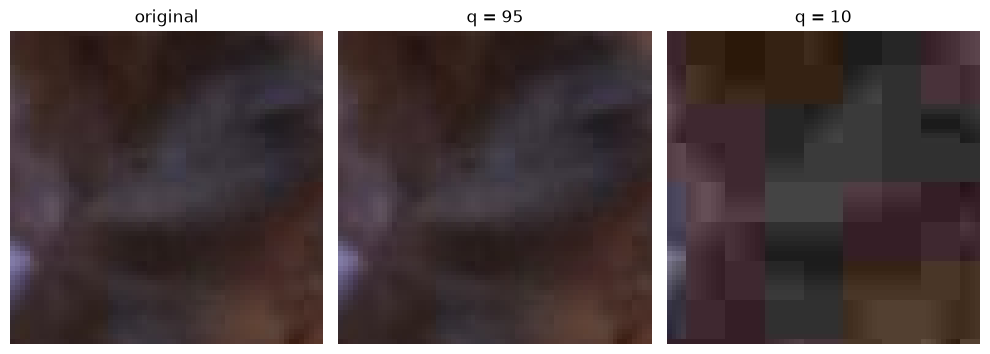

In [18]:
# 64x64 crop in the centre, shown enlarged: original vs q=95 vs q=10
cy, cx = orig.shape[0] // 2, orig.shape[1] // 2
crop = lambda a: a[cy - 32:cy + 32, cx - 32:cx + 32]
fig, axes = plt.subplots(1, 3, figsize=(10, 3.6))
for ax, (title, a) in zip(axes, [("original", orig), ("q = 95", decoded[95]), ("q = 10", decoded[10])]):
    ax.imshow(crop(a), interpolation="nearest"); ax.set_title(title); ax.axis("off")
fig.tight_layout()

Note the odd result: q = 75 gives a *higher* PSNR than q = 95. The source file was most likely saved with the same quantisation tables as q = 75, so re-saving at 75 almost reproduces it, while q = 95 uses different tables and re-quantises everything.

**Answer (b).** The images are already JPEG files, so they already carry 8×8 block artefacts. Re-compressing them adds a second layer of artefacts (PSNR drops quickly below q≈50 and the q=10 crop is visibly blocky), and resizing blurs the block edges into patterns that depend on the original quality setting.
If quality or compression differs between classes (e.g. images from different clinics or cameras), a CNN can learn these **compression patterns instead of skin features** — a shortcut that will not transfer to new devices.

,image_type,AUC(file size -> Malignant),median kB Benign,median kB Malignant
0,dermoscopic,0.481,26.2,25.8
1,clinical: close-up,0.505,38.8,38.8


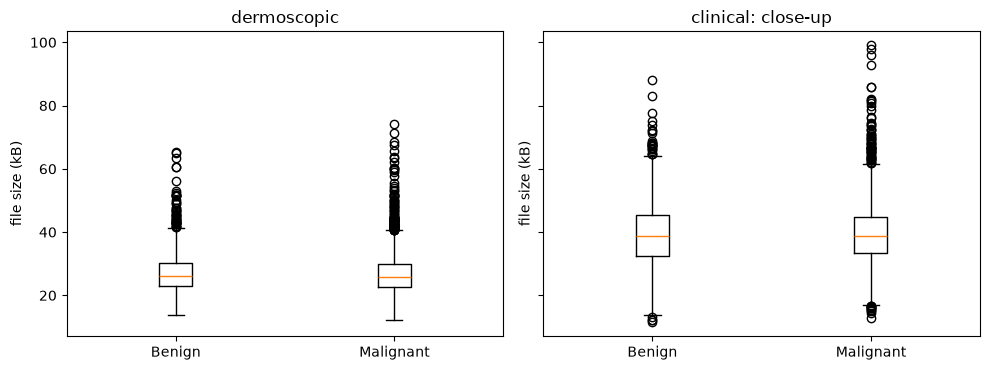

In [19]:
# (c) file size vs label: os.stat is fast and decodes nothing
from sklearn.metrics import roc_auc_score

labelled["file_kB"] = [os.stat(image_path(i)).st_size / 1024 for i in labelled.isic_id]
bm = labelled[labelled.diagnosis_1.isin(["Benign", "Malignant"])]

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), sharey=True)
auc_rows = []
for ax, itype in zip(axes, [config.DERM, config.CLINICAL]):
    sub = bm[bm.image_type == itype]
    ax.boxplot([sub.loc[sub.diagnosis_1 == c, "file_kB"] for c in ["Benign", "Malignant"]])
    ax.set_xticks([1, 2], ["Benign", "Malignant"])
    ax.set_title(itype); ax.set_ylabel("file size (kB)")
    auc = roc_auc_score(sub.diagnosis_1 == "Malignant", sub.file_kB)
    auc_rows.append({"image_type": itype, "AUC(file size -> Malignant)": round(auc, 3),
                     "median kB Benign": round(sub.loc[sub.diagnosis_1 == "Benign", "file_kB"].median(), 1),
                     "median kB Malignant": round(sub.loc[sub.diagnosis_1 == "Malignant", "file_kB"].median(), 1)})
fig.tight_layout()
fig.savefig(config.FIG_DIR / "a2_file_size_by_class.png", dpi=120, bbox_inches="tight")
pd.DataFrame(auc_rows)

**Answer (c).** In this copy of MILK10k the file size carries almost no label information: AUC = 0.48 (dermoscopic) and 0.51 (clinical), and the medians are practically equal. That fits the fact that every image here was re-encoded to the same 600×450 size.
In general an AUC far from 0.5 would mean a **shortcut**: file size reflects the camera or clinic, the original resolution, the crop and how malignant cases were collected — none of which is skin biology. Even with no measurable effect here, we resize every image to the same size and never give file size (or other file properties) to the model.

# A3 — Splits, leakage, metrics, augmentation, Dataset

## A3.1 Measure the leak
Image-level table, features = age, sex, site, image type; target = `diagnosis_1`.

In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import StratifiedGroupKFold, train_test_split
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder

images = labelled.reset_index(drop=True)
num_cols = ["age_approx"]
cat_cols = ["sex", "anatom_site_general", "image_type"]
X, y, groups = images[num_cols + cat_cols], images.diagnosis_1, images.lesion_id

def make_model(seed):
    pre = ColumnTransformer([
        ("cat", make_pipeline(SimpleImputer(strategy="most_frequent"), OneHotEncoder(handle_unknown="ignore")), cat_cols),
        ("num", SimpleImputer(strategy="median"), num_cols),
    ])
    return Pipeline([("pre", pre), ("rf", RandomForestClassifier(min_samples_leaf=1, random_state=seed, n_jobs=-1))])

# sibling = the other image of the same lesion
sibling = images.groupby("lesion_id").isic_id.transform(lambda s: s.iloc[::-1].values)
label_of = images.set_index("isic_id").diagnosis_1

def sibling_oracle(train_idx, test_idx):
    """Predict the label of the sibling image if it is in train, else the train majority class."""
    train_ids = set(images.isic_id.iloc[train_idx])
    majority = y.iloc[train_idx].mode()[0]
    sib = sibling.iloc[test_idx]
    in_train = sib.isin(train_ids)
    pred = np.where(in_train, label_of.reindex(sib).values, majority)
    return balanced_accuracy_score(y.iloc[test_idx], pred), in_train.mean()

rows = []
for seed in range(5):
    # (a) naive split on images
    tr, te = train_test_split(np.arange(len(images)), test_size=0.2, stratify=y, random_state=seed)
    # (b) grouped split: first fold of StratifiedGroupKFold
    tr_g, te_g = next(StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=seed).split(X, y, groups))
    for name, (a, b) in {"naive": (tr, te), "grouped": (tr_g, te_g)}.items():
        model = make_model(seed).fit(X.iloc[a], y.iloc[a])
        bacc = balanced_accuracy_score(y.iloc[b], model.predict(X.iloc[b]))
        oracle, frac = sibling_oracle(a, b)
        rows.append({"seed": seed, "split": name, "RF bal. acc": bacc, "oracle bal. acc": oracle, "% test with sibling in train": 100 * frac})

leak = pd.DataFrame(rows)
summary = leak.groupby("split")[["RF bal. acc", "oracle bal. acc", "% test with sibling in train"]].agg(["mean", "std"]).round(3)
summary

RF bal. acc        oracle bal. acc        % test with sibling in train       
               mean    std            mean    std                         mean    std
split                                                                                
grouped       0.426  0.005           0.333  0.000                         0.00  0.000
naive         0.424  0.006           0.847  0.022                        79.79  1.211

In [21]:
for split, g in leak.groupby("split"):
    print(f"{split:8s} RF {g['RF bal. acc'].mean():.3f} ± {g['RF bal. acc'].std():.3f} | "
          f"oracle {g['oracle bal. acc'].mean():.3f} ± {g['oracle bal. acc'].std():.3f} | "
          f"sibling in train {g['% test with sibling in train'].mean():.0f} %")

grouped  RF 0.426 ± 0.005 | oracle 0.333 ± 0.000 | sibling in train 0 %
naive    RF 0.424 ± 0.006 | oracle 0.847 ± 0.022 | sibling in train 80 %


**Conclusion A3.1 (d).** With the naive image split, about 80 % of test images have their sibling (the other view of the same lesion) in the training set; with the grouped split, 0 %.
The random forest only sees age, sex, site and image type — weak, lesion-level signals shared by both images — so its score changes little between the two splits. The **sibling oracle** shows the real danger: a model that simply *recognises the lesion* reaches a very high balanced accuracy on the naive split without learning anything about diagnosis. A CNN looking at the pixels can do exactly that.
"No measured inflation" for a weak model does not prove there is no leak for a stronger one, so we **always split by lesion**.

## A3.2 Three-way split (`src/splits.py`)
`split_lesions()` is implemented in `src/splits.py` and tested in `tests/test_splits.py` (no overlap, sizes within ±1 pp, same seed → same split, over 10 seeds).

In [22]:
from src.splits import split_lesions

train_ids, val_ids, test_ids = split_lesions(lesion_table, val_size=0.15, test_size=0.15, seed=SEED)
n = len(lesion_table)
print(f"train {len(train_ids)} ({len(train_ids)/n:.1%}) | val {len(val_ids)} ({len(val_ids)/n:.1%}) | test {len(test_ids)} ({len(test_ids)/n:.1%})")
assert not set(train_ids) & set(val_ids) and not set(train_ids) & set(test_ids) and not set(val_ids) & set(test_ids)

train 3742 (71.4%) | val 749 (14.3%) | test 749 (14.3%)


In [23]:
# Rare classes: how often does a seed put at least one lesion of the class in BOTH val and test?
rare = ["MAL_OTH", "DF", "INF", "VASC", "BEN_OTH"]
dx_of = lesion_table.set_index("lesion_id").dx
counts = {c: [] for c in rare}
both = {c: 0 for c in rare}
for seed in range(10):
    _, v, t = split_lesions(lesion_table, 0.15, 0.15, seed)
    for c in rare:
        nv, nt = (dx_of[v] == c).sum(), (dx_of[t] == c).sum()
        counts[c].append((nv, nt))
        both[c] += (nv > 0) and (nt > 0)
pd.DataFrame({
    "lesions in data": [(dx_of == c).sum() for c in rare],
    "seeds with class in val AND test (of 10)": [both[c] for c in rare],
    "test count range": [f"{min(t for _, t in counts[c])}–{max(t for _, t in counts[c])}" for c in rare],
}, index=rare)

,lesions in data,seeds with class in val AND test (of 10),test count range
MAL_OTH,9,10,1–2
DF,52,10,7–8
INF,50,10,7–8
VASC,47,10,6–7
BEN_OTH,44,10,6–7


**Answer A3.2.** Stratification works: even MAL_OTH (9 lesions) lands in both val and test for every seed. But the test set then holds only **1–2 MAL_OTH lesions** and about 6–8 lesions of DF, INF, VASC and BEN_OTH. A single misclassified case changes the class recall by 50–100 % (MAL_OTH) or 12–15 % (the others), so rare-class metrics on test are **very noisy** and must be read with confidence intervals or pooled across folds.

## A3.3 Compare three 5-fold strategies

In [24]:
from sklearn.model_selection import GroupKFold, StratifiedKFold

def evaluate_folds(fold_of_image):
    """fold_of_image: Series (index = images.index) with the val fold of every image."""
    per_lesion = fold_of_image.groupby(images.lesion_id).nunique()
    leaked = int((per_lesion > 1).sum())
    props = pd.crosstab(fold_of_image, images.dx, normalize="index")      # class share per val fold
    spread = ((props.max() - props.min()) * 100).max()
    no_mal_oth = int((pd.crosstab(fold_of_image, images.dx).get("MAL_OTH", 0) == 0).sum())
    return {"leaked lesions": leaked, "max class-share spread (pp)": round(spread, 2), "folds without MAL_OTH": no_mal_oth}

def folds_from(splitter, table, y=None, groups=None):
    fold = pd.Series(-1, index=table.index)
    for k, (_, val_idx) in enumerate(splitter.split(table, y, groups)):
        fold.iloc[val_idx] = k
    return fold

lt_idx = lesion_table.set_index("lesion_id")
to_images = lambda lesion_fold: images.lesion_id.map(pd.Series(lesion_fold.values, index=lesion_table.lesion_id))

res = {
    "(i) GroupKFold on lesions": evaluate_folds(to_images(folds_from(GroupKFold(n_splits=5), lesion_table, groups=lesion_table.lesion_id))),
    "(ii) StratifiedKFold on images": evaluate_folds(folds_from(StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED), images, y=images.dx)),
    "(iii) StratifiedGroupKFold on lesions": evaluate_folds(to_images(folds_from(StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED), lesion_table, y=lesion_table.dx, groups=lesion_table.lesion_id))),
}
pd.DataFrame.from_dict(res, orient="index")

,leaked lesions,max class-share spread (pp),folds without MAL_OTH
(i) GroupKFold on lesions,0,3.63,0
(ii) StratifiedKFold on images,4158,0.05,0
(iii) StratifiedGroupKFold on lesions,0,0.10,0


**Conclusion A3.3.** (ii) StratifiedKFold on images has perfectly balanced classes but leaks: most lesions have their two images in different folds.
(i) GroupKFold never leaks but ignores the labels, so class shares drift between folds (up to 3.6 pp here). With 9 MAL_OTH lesions every fold happened to get one, but nothing guarantees it — a smaller class or another dataset can leave a fold without any.
(iii) **StratifiedGroupKFold** is the winner: no leak *and* stable class proportions in every fold — it is what `split_lesions` uses.

## A3.4 Metrics and cost
Dummy baselines on the lesion-level split from A3.2 (target `diagnosis_1`).

In [25]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, confusion_matrix, f1_score

dx1 = config.DX1_CLASSES                          # ["Benign", "Indeterminate", "Malignant"]
lt = lesion_table.set_index("lesion_id")
y_train, y_test = lt.loc[train_ids, "diagnosis_1"], lt.loc[test_ids, "diagnosis_1"]
X_train, X_test = np.zeros((len(y_train), 1)), np.zeros((len(y_test), 1))   # dummies ignore X

dummies = {
    "always Malignant": DummyClassifier(strategy="constant", constant="Malignant"),
    "always Benign": DummyClassifier(strategy="constant", constant="Benign"),
    "stratified": DummyClassifier(strategy="stratified", random_state=SEED),
    "uniform": DummyClassifier(strategy="uniform", random_state=SEED),
}
preds = {name: d.fit(X_train, y_train).predict(X_test) for name, d in dummies.items()}
metrics = pd.DataFrame({
    name: {"accuracy": accuracy_score(y_test, p),
           "balanced accuracy": balanced_accuracy_score(y_test, p),
           "macro F1": f1_score(y_test, p, average="macro", zero_division=0)}
    for name, p in preds.items()}).T.round(3)
metrics

,accuracy,balanced accuracy,macro F1
always Malignant,0.694,0.333,0.273
always Benign,0.283,0.333,0.147
stratified,0.550,0.323,0.322
uniform,0.352,0.360,0.284


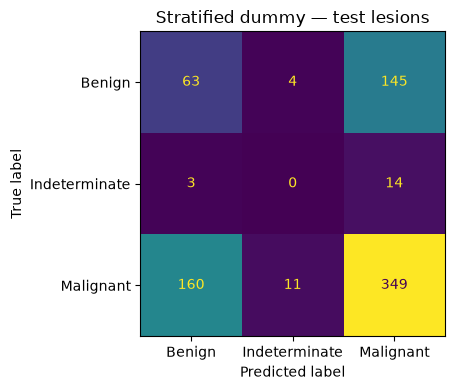

In [26]:
fig, ax = plt.subplots(figsize=(4.5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, preds["stratified"], labels=dx1, ax=ax, colorbar=False)
ax.set_title("Stratified dummy — test lesions")
fig.tight_layout()

**(b) Cost matrix** (rows = truth, columns = prediction).
Missed malignancy (Malignant → Benign) = 50; benign lesion flagged (Benign → Indeterminate or Malignant) = 1;
errors involving Indeterminate (Indeterminate → anything else, Malignant → Indeterminate) = 5 — a malignant lesion called Indeterminate still gets follow-up, so it is much cheaper than calling it Benign; correct = 0.

In [27]:
cost = pd.DataFrame([[0, 1, 1],
                     [5, 0, 5],
                     [50, 5, 0]], index=dx1, columns=dx1)
print(cost, "\n")

def expected_cost(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=dx1)
    return (cm * cost.values).sum() / len(y_true)

preds["always Indeterminate"] = np.full(len(y_test), "Indeterminate")
metrics.loc["always Indeterminate", ["accuracy", "balanced accuracy", "macro F1"]] = [
    accuracy_score(y_test, preds["always Indeterminate"]),
    balanced_accuracy_score(y_test, preds["always Indeterminate"]),
    f1_score(y_test, preds["always Indeterminate"], average="macro", zero_division=0)]
metrics["expected cost"] = [expected_cost(y_test, preds[name]) for name in metrics.index]
metrics["rank by accuracy"] = metrics.accuracy.rank(ascending=False, method="min").astype(int)
metrics["rank by cost"] = metrics["expected cost"].rank(method="min").astype(int)
metrics.round(3).sort_values("expected cost")

               Benign  Indeterminate  Malignant
Benign              0              1          1
Indeterminate       5              0          5
Malignant          50              5          0 



,accuracy,balanced accuracy,macro F1,expected cost,rank by accuracy,rank by cost
always Malignant,0.694,0.333,0.273,0.397,1,1
always Indeterminate,0.023,0.333,0.015,3.754,5,2
stratified,0.550,0.323,0.322,11.067,2,3
uniform,0.352,0.360,0.284,13.483,3,4
always Benign,0.283,0.333,0.147,34.826,4,5


In [28]:
# (c) cost of every constant prediction
const_cost = {c: expected_cost(y_test, np.full(len(y_test), c)) for c in dx1}
print({k: round(float(v), 3) for k, v in const_cost.items()}, "-> cheapest constant:", min(const_cost, key=const_cost.get))

{'Benign': 34.826, 'Indeterminate': 3.754, 'Malignant': 0.397} -> cheapest constant: Malignant


**Answer A3.4.** Accuracy rewards the majority class: *always Malignant* reaches 69 % accuracy with a balanced accuracy of only 33 % — no better than guessing.
With the cost matrix the cheapest constant prediction is also *always Malignant* (expected cost 0.40 per lesion: a false alarm costs 1, a missed cancer 50).
But the two rankings do **not** match overall: *always Indeterminate* has the worst accuracy (2 %) yet is the second-cheapest strategy (3.75), because it never sends a cancer home; *always Benign* ranks 4th on accuracy but is by far the most expensive (34.8).
So accuracy alone would pick the wrong model. We report **balanced accuracy and Malignant recall**, and keep the clinical cost of each error type in mind.